In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
data=pd.read_csv('data/credit.csv')
data.head()

,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
1,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
2,104.593,7075,514,4,71,11,Male,No,No,Asian,580
3,148.924,9504,681,3,36,11,Female,No,No,Asian,964
4,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331


# reshape

In [21]:
# reshape
d_edu=data.pivot(columns='Gender',values='Balance') # parameter: index,aggfunc; similar: pivot_table

d_melt=pd.melt(data,
                id_vars= 'Student',
                value_vars=['Education','Age'], # melted one
                var_name='student', # new name cannot repeat
                value_name='year')# new name cannot repeat

# preview
d_edu.info()
d_melt.describe()
data.head()

<class 'pandas.core.frame.DataFrame'>
Index: 400 entries, 0 to 399
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0    Male   193 non-null    float64
 1   Female  207 non-null    float64
dtypes: float64(2)
memory usage: 9.4 KB


,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
1,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
2,104.593,7075,514,4,71,11,Male,No,No,Asian,580
3,148.924,9504,681,3,36,11,Female,No,No,Asian,964
4,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331


# encoding

In [22]:
# encoding the dicrested feature
encoding = pd.get_dummies(data[['Ethnicity', 'Married']])# return bool

## return number
encoding['health'] = np.where(data['Gender'] == 'Male', 1, 0)

encoding['male'] = (data.Gender == 'Male').astype(int)

from sklearn import preprocessing  
le = preprocessing.LabelEncoder()
encoding['Ethnicity'] = le.fit_transform(data['Ethnicity'])
encoding.head()

,Ethnicity_African American,Ethnicity_Asian,Ethnicity_Caucasian,Married_No,Married_Yes,health,male,Ethnicity
0,False,False,True,False,True,0,0,2
1,False,True,False,False,True,0,0,1
2,False,True,False,True,False,0,0,1
3,False,True,False,True,False,0,0,1
4,False,False,True,False,True,0,0,2


# drop

In [23]:
# drop and calculate the correlation
data.drop(columns=['Ethnicity','Married','Gender','Student']).corr()

# drop the missing value
data = data.dropna().drop('Unnamed: 0', axis=1,errors='ignore')

# standardization

In [24]:
# standardization
from sklearn.preprocessing import scale 
scale(data.Income)

from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[['Income']])

# FB selection

In [25]:
# FB selection
import itertools
import time
import statsmodels.api as sm

dummies = pd.get_dummies(data[['Ethnicity', 'Married','Student','Gender']])

y = data.Balance
X_ = data.drop(['Ethnicity', 'Married', 'Student', 'Gender','Balance'], axis=1).astype('float64')
X = pd.concat([X_, dummies[['Ethnicity_Asian', 'Married_Yes','Student_Yes','Gender_Female']]], axis=1)

def processSubset(feature_set):
    # Fit model on feature_set and calculate RSS
    model = sm.OLS(y,X[list(feature_set)].astype(float))## match your model
    regr = model.fit()
    RSS = ((regr.predict(X[list(feature_set)]) - y) ** 2).sum()
    return {"model":regr, "RSS":RSS}

In [26]:
# both
def getBest(k):
    
    tic = time.time()
    
    results = []
    
    for combo in itertools.combinations(X.columns, k):
        results.append(processSubset(combo))
    
    # Wrap everything up in a nice dataframe
    models = pd.DataFrame(results)
    
    # Choose the model with the highest RSS
    best_model = models.loc[models['RSS'].argmin()]
    
    toc = time.time()
    print("Processed", models.shape[0], "models on", k, "predictors in", (toc-tic), "seconds.")
    
    # Return the best model, along with some other useful information about the model
    return best_model
    
models_best = pd.DataFrame(columns=["RSS", "model"])

tic = time.time()
for i in range(1,5):
    models_best.loc[i] = getBest(i)

toc = time.time()
print("Total elapsed time:", (toc-tic), "seconds.")
print(models_best)
print(models_best.loc[2, "model"].summary())# the number base on above, find the lowest SSR
# print(getBest(17)["model"].summary())

Processed 10 models on 1 predictors in 0.08436179161071777 seconds.
Processed 45 models on 2 predictors in 0.1801624298095703 seconds.
Processed 120 models on 3 predictors in 0.38682985305786133 seconds.
Processed 210 models on 4 predictors in 0.6042249202728271 seconds.
Total elapsed time: 1.272099256515503 seconds.
               RSS                                              model
1  28284986.044848  <statsmodels.regression.linear_model.Regressio...
2  21593382.928211  <statsmodels.regression.linear_model.Regressio...
3   13469879.75724  <statsmodels.regression.linear_model.Regressio...
4   6993371.313434  <statsmodels.regression.linear_model.Regressio...
                                 OLS Regression Results                                
Dep. Variable:                Balance   R-squared (uncentered):                   0.888
Model:                            OLS   Adj. R-squared (uncentered):              0.887
Method:                 Least Squares   F-statistic:               

In [27]:
# backward
def backward(predictors):
    
    tic = time.time()
    
    results = []
    
    for combo in itertools.combinations(predictors, len(predictors)-1):
        results.append(processSubset(combo))
    
    # Wrap everything up in a nice dataframe
    models = pd.DataFrame(results)
    
    # Choose the model with the highest RSS
    best_model = models.loc[models['RSS'].argmin()]
    
    toc = time.time()
    print("Processed ", models.shape[0], "models on", len(predictors)-1, "predictors in", (toc-tic), "seconds.")
    
    # Return the best model, along with some other useful information about the model
    return best_model

models_bwd = pd.DataFrame(columns=["RSS", "model"], index = range(1,len(X.columns)))

tic = time.time()
predictors = X.columns

while(len(predictors) > 1):  
    models_bwd.loc[len(predictors)-1] = backward(predictors)
    predictors = models_bwd.loc[len(predictors)-1]["model"].model.exog_names

toc = time.time()
print("Total elapsed time", (toc-tic), "seconds.")
print(models_bwd)
print(models_bwd.loc[3, "model"].params)

Processed  10 models on 9 predictors in 0.06052589416503906 seconds.
Processed  9 models on 8 predictors in 0.03900265693664551 seconds.
Processed  8 models on 7 predictors in 0.03200578689575195 seconds.
Processed  7 models on 6 predictors in 0.02600574493408203 seconds.
Processed  6 models on 5 predictors in 0.019003868103027344 seconds.
Processed  5 models on 4 predictors in 0.0180051326751709 seconds.
Processed  4 models on 3 predictors in 0.012005090713500977 seconds.
Processed  3 models on 2 predictors in 0.009002923965454102 seconds.
Processed  2 models on 1 predictors in 0.007002830505371094 seconds.
Total elapsed time 0.23155641555786133 seconds.
               RSS                                              model
1  28284986.044848  <statsmodels.regression.linear_model.Regressio...
2  21593382.928211  <statsmodels.regression.linear_model.Regressio...
3   13469879.75724  <statsmodels.regression.linear_model.Regressio...
4   6993371.313434  <statsmodels.regression.linear_model

In [28]:
# forward
def forward(predictors):

    # Pull out predictors we still need to process
    remaining_predictors = [p for p in X.columns if p not in predictors]
    
    tic = time.time()
    
    results = []
    
    for p in remaining_predictors:
        results.append(processSubset(predictors+[p]))
    
    # Wrap everything up in a nice dataframe
    models = pd.DataFrame(results)
    
    # Choose the model with the highest RSS
    best_model = models.loc[models['RSS'].argmin()]
    
    toc = time.time()
    print("Processed ", models.shape[0], "models on", len(predictors)+1, "predictors in", (toc-tic), "seconds.")
    
    # Return the best model, along with some other useful information about the model
    return best_model

models_fwd = pd.DataFrame(columns=["RSS", "model"])

tic = time.time()
predictors = []

for i in range(1,len(X.columns)+1):    
    models_fwd.loc[i] = forward(predictors)
    predictors = models_fwd.loc[i]["model"].model.exog_names

toc = time.time()
print("Total elapsed time:", (toc-tic), "seconds.")
print(models_fwd)
print(models_fwd.loc[3, "model"].summary())

Processed  10 models on 1 predictors in 0.042009830474853516 seconds.
Processed  9 models on 2 predictors in 0.02400517463684082 seconds.
Processed  8 models on 3 predictors in 0.01900506019592285 seconds.
Processed  7 models on 4 predictors in 0.01900315284729004 seconds.
Processed  6 models on 5 predictors in 0.01801133155822754 seconds.
Processed  5 models on 6 predictors in 0.01899266242980957 seconds.
Processed  4 models on 7 predictors in 0.015002012252807617 seconds.
Processed  3 models on 8 predictors in 0.0110015869140625 seconds.
Processed  2 models on 9 predictors in 0.009001970291137695 seconds.
Processed  1 models on 10 predictors in 0.00600433349609375 seconds.
Total elapsed time: 0.2020556926727295 seconds.
                RSS                                              model
1   28284986.044848  <statsmodels.regression.linear_model.Regressio...
2   21593382.928211  <statsmodels.regression.linear_model.Regressio...
3    13469879.75724  <statsmodels.regression.linear_mod

# pca

In [6]:
from sklearn.decomposition import PCA

X=data[['Income','Education','Age','Cards','Rating','Limit']]
pca_loadings = pd.DataFrame(PCA().fit(X).components_.T, index=X.columns, columns=['V1', 'V2', 'V3', 'V4','V5','V6'])
pca_loadings

# Fit the PCA model and transform X to get the principal components
pca = PCA(4)
df_plot = pd.DataFrame(pca.fit_transform(X), columns=['PC1', 'PC2', 'PC3', 'PC4'], index=X.index)
df_plot.head()

,PC1,PC2,PC3,PC4
0,-1132.182430,-21.973559,-14.783365,4.704382
1,1914.303173,43.398213,12.499278,-1.388274
2,2345.356301,33.779182,3.743878,1.604615
3,4780.416543,37.230223,-35.720660,7.272409
4,161.304274,11.658437,8.785578,-9.464412


In [7]:
pd.DataFrame([df_plot.iloc[:,:4].std(axis=0, ddof=0).to_numpy(),
              pca.explained_variance_ratio_[:4],
              np.cumsum(pca.explained_variance_ratio_[:4])],
             index=['Standard Deviation',# the scale of the info
                    'Proportion of Variance', 'Cumulative Proportion'],# contribution
             columns=['PC1', 'PC2', 'PC3','PC4'])

,PC1,PC2,PC3,PC4
Standard Deviation,2310.622112,21.908205,16.610084,12.177258
Proportion of Variance,0.999829,0.000090,0.000052,0.000028
Cumulative Proportion,0.999829,0.999919,0.999970,0.999998


# train and test

In [8]:
# trian and test
from sklearn.model_selection import train_test_split
X_train1, X_test1, y_train1, y_test1 = train_test_split(data.drop(['Balance'],axis=1),data['Balance'], test_size=0.5, random_state=1)
X_train2, X_test2, y_train2, y_test2 = train_test_split(df_plot,np.where(data['Student'] == 'Yes', 1, 0), test_size=0.5, random_state=1)

# CV

In [9]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
from sklearn.model_selection import cross_val_score, LeaveOneOut
loo = LeaveOneOut()
loo.get_n_splits(X_train2)
scores = cross_val_score(lm, X_train2, y_train1,
                         scoring="neg_mean_squared_error",
                         cv=loo, n_jobs=1)

print("Folds: " + str(len(scores)) + ", MSE: " + str(np.mean(np.abs(scores))) + ", STD: " + str(np.std(scores)))

Folds: 200, MSE: 27284.273946214584, STD: 51483.103618499525


In [10]:
from sklearn.model_selection import KFold

crossvalidation = KFold(n_splits=200, random_state=None, shuffle=False) # N=392
model = lm.fit(X_train2, y_train1)
scores = cross_val_score(model, X_train2, y_train1, scoring="neg_mean_squared_error", cv=crossvalidation,n_jobs=1)

print("Folds: " + str(len(scores)) + ", MSE: " + str(np.mean(np.abs(scores))) + ", STD: " + str(np.std(scores)))

Folds: 200, MSE: 27284.273946214584, STD: 51483.103618499525


In [11]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
crossvalidation = KFold(n_splits=10, shuffle=False)
lm = LinearRegression()

for i in range(1,6):
    poly = PolynomialFeatures(degree=i)
    X_current = poly.fit_transform(X_train2)
    model = lm.fit(X_current, y_train1)
    scores = cross_val_score(model, X_current, y_train1, scoring="neg_mean_squared_error", cv=crossvalidation,
 n_jobs=1)
    
    print("Degree-"+str(i)+" polynomial MSE: " + str(np.mean(np.abs(scores))) + ", STD: " + str(np.std(scores)))

Degree-1 polynomial MSE: 28117.809742620164, STD: 15631.320750892328
Degree-2 polynomial MSE: 26537.52927319457, STD: 17084.299526174855
Degree-3 polynomial MSE: 30889.278511436685, STD: 23722.732880456362
Degree-4 polynomial MSE: 253431.57649754136, STD: 442580.89879408095
Degree-5 polynomial MSE: 1563858.0626186468, STD: 2521165.0834224643


# booststrap

In [27]:
def alpha(X, Y):
    cov_xy = np.cov(X, Y)   # 协方差标量
    var_x = np.var(X)
    var_y = np.var(Y)
    return (var_y - cov_xy) / (var_x + var_y - 2 * cov_xy)

X = X_train2.PC1.values[0:100]
y = y_train1.values[0:100]
df = pd.DataFrame({"X": X.ravel(), "Y": y})
print(alpha(X,y))

# Xsamp, ysamp = resample(X, y, n_samples=1000)
dfsample = df.sample(frac=1, replace=True)
X = dfsample.X[0:100]
y = dfsample.Y[0:100]
print(alpha(X,y))

[[ 9.89751410e-01 -1.91413915e-01]
 [-1.91413915e-01 -3.62305009e-04]]
[[ 9.89717400e-01 -1.93768656e-01]
 [-1.93768656e-01 -3.97810297e-04]]


In [29]:
def bstrap(df):# 1000 times booststrap
    tresult = 0
    for i in range(0,1000):
        dfsample = df.sample(frac=1, replace=True)
        X = dfsample.X[0:100]
        y = dfsample.Y[0:100]
        result = alpha(X,y)
        tresult += result
    fresult = tresult / 1000
    print(fresult)
    
bstrap(df)

[[ 9.89745386e-01 -1.92077637e-01]
 [-1.92077637e-01 -3.68598866e-04]]


# linear regression

In [49]:
import statsmodels.formula.api as smf
results = smf.ols('Balance ~ Age + Income', data=data).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Balance   R-squared:                       0.221
Model:                            OLS   Adj. R-squared:                  0.218
Method:                 Least Squares   F-statistic:                     56.47
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           2.60e-22
Time:                        17:22:05   Log-Likelihood:                -2969.3
No. Observations:                 400   AIC:                             5945.
Df Residuals:                     397   BIC:                             5957.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    359.6727     70.358      5.112      0.000     221.351     497.994
Age           -2.1851      1.199     -1.823      0.069      -4.542       0.172
Income         6.2359      0.587     10.628      0.000       5.082       7.389
==============================================================================
Omnibus:                       42.191   Durbin-Watson:                   1.947
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               20.272
Skew:                           0.369   Prob(JB):                     3.96e-05
Kurtosis:                       2.180   Cond. No.                         267.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [50]:
from statsmodels.stats.anova import anova_lm
anova_lm(results)

,df,sum_sq,mean_sq,F,PR(>F)
Age,1.0,2.840283e+02,2.840283e+02,0.001717,9.669653e-01
Income,1.0,1.868031e+07,1.868031e+07,112.947916,2.197302e-23
Residual,397.0,6.565932e+07,1.653887e+05,NaN,NaN


# pcr

In [59]:
from sklearn.preprocessing import scale 
from sklearn import model_selection
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.cross_decomposition import PLSRegression, PLSSVD
from sklearn.metrics import mean_squared_error

pca = PCA()
X_train1=X_train1.drop(columns=['Ethnicity','Married','Gender','Student'],axis=0)
X_test1=X_test1.drop(columns=['Ethnicity','Married','Gender','Student'],axis=0)
X_reduced_train = pca.fit_transform(scale(X_train1))
X_reduced_test = pca.fit_transform(scale(X_test1))
# Train regression model on training data 
regr = LinearRegression()
regr.fit(X_reduced_train[:,:6], y_train1)

# Prediction with test data
pred = regr.predict(X_reduced_test)
mean_squared_error(y_test1, pred)

50021.452582934995

# plsr

In [61]:
from sklearn.preprocessing import scale 
from sklearn import model_selection
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.cross_decomposition import PLSRegression, PLSSVD
from sklearn.metrics import mean_squared_error

pls = PLSRegression(n_components=3)
pls.fit(scale(X_train1), y_train1)

mean_squared_error(y_test1, pls.predict(scale(X_test1)))

27036.584951607165

# Lasso and ridge regression (regularization for overfitting)

In [62]:
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, RidgeCV, Lasso, LassoCV
from sklearn.metrics import mean_squared_error

ridge2 = Ridge(alpha = 4)
ridge2.fit(X_train1, y_train1)             # Fit a ridge regression on the training data
pred2 = ridge2.predict(X_test1)           # Use this model to predict the test data
print(pd.Series(ridge2.coef_, index = X.columns)) # Print coefficients
print(mean_squared_error(y_test1, pred2))          # Calculate the test MSE

Income      -7.386705
Education    0.065133
Age          2.935503
Cards        8.512897
Rating      -0.601989
Limit        0.784042
dtype: float64
25852.015686495182


In [64]:
###  use cross-validation to choose the tuning parameter alpha. 
alphas = 10**np.linspace(10,-2,100)*0.5
ridgecv = RidgeCV(alphas = alphas, scoring = 'neg_mean_squared_error')
ridgecv.fit(X_train1, y_train1)
ridgecv.alpha_

np.float64(3289.6661232878414)

In [67]:
lassocv = LassoCV(alphas = None, cv = 10, max_iter = 100000)
lassocv.fit(X_train1, y_train1)

lasso = Lasso(max_iter = 10000)
lasso.set_params(alpha=lassocv.alpha_)
lasso.fit(X_train1, y_train1)
mean_squared_error(y_test1, lasso.predict(X_test1))

D:\install\anaconda\envs\good\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1641: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(


29203.15953414683

# polynomial

In [9]:
from sklearn.preprocessing import PolynomialFeatures
import statsmodels.api as sm
# linear model
X = PolynomialFeatures(3).fit_transform(data.Age.values.reshape(-1,1))
fit = sm.GLS(data.Balance, X).fit()
fit.summary()
#print(sm.stats.anova_lm(fit_1, fit_2, fit_3, fit_4, fit_5, typ=1))

<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:                Balance   R-squared:                       0.032
Model:                            GLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     4.415
Date:                Wed, 01 Jul 2026   Prob (F-statistic):            0.00454
Time:                        09:55:25   Log-Likelihood:                -3012.8
No. Observations:                 400   AIC:                             6034.
Df Residuals:                     396   BIC:                             6050.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1618.0643    658.827     -2.456      0.014   -2913.301    -322.828
x1           133.0473     38.800      3.429      0.001      56.768     209.327
x2            -2.5562      0.720     -3.550      0.000      -3.972      -1.141
x3             0.0154      0.004      3.617      0.000       0.007       0.024
==============================================================================
Omnibus:                       42.267   Durbin-Watson:                   1.898
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               26.183
Skew:                           0.492   Prob(JB):                     2.06e-06
Kurtosis:                       2.224   Cond. No.                     8.27e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.27e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [8]:
# logistic model（0/1）
y = (data.Balance > 250).map({False:0, True:1}).to_numpy()
clf = sm.GLM(y, X, family=sm.families.Binomial(sm.families.links.logit()))
res = clf.fit()
age_grid = np.arange(data.Age.min(), data.Age.max()).reshape(-1,1) # 得到平滑的预测
X_test = PolynomialFeatures(3).fit_transform(age_grid)
pred = res.predict(X_test)  # Pr(balance>250)
print(pred)

[0.42468206 0.45696298 0.48721539 0.51524199 0.54093976 0.56428265
 0.58530367 0.60407822 0.62070979 0.63531837 0.64803154 0.658978
 0.66828307 0.67606584 0.68243751 0.6875007  0.69134938 0.69406921
 0.69573824 0.69642781 0.69620347 0.69512602 0.69325253 0.69063735
 0.68733306 0.68339131 0.67886371 0.67380246 0.66826107 0.66229477
 0.65596097 0.64931955 0.64243297 0.63536638 0.62818753 0.62096662
 0.61377606 0.60669019 0.59978487 0.59313719 0.58682499 0.58092659
 0.57552038 0.57068456 0.56649691 0.56303459 0.56037394 0.55859045
 0.55775853 0.55795142 0.55924086 0.56169678 0.56538659 0.5703744
 0.57671966 0.5844755  0.59368646 0.60438565 0.61659127 0.63030255
 0.64549511 0.66211611 0.68007936 0.69926107 0.71949662 0.7405794
 0.7622622  0.78426201 0.80626843 0.82795584 0.84899843 0.86908707
 0.88794621 0.90534893 0.92112827]


D:\install\anaconda\envs\good\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The logit link alias is deprecated. Use Logit instead. The logit link alias will be removed after the 0.15.0 release.
  warnings.warn(


# piecewise

In [11]:
# linear model
df_cut, bins = pd.cut(data.Age, 4, retbins = True, right = True)
df_cut.value_counts(sort = False)
df_steps = pd.concat([data.Age, df_cut, data.Balance], keys = ['age','age_cuts','wage'], axis = 1)

# Create dummy variables for the age groups
df_steps_dummies = pd.get_dummies(df_steps['age_cuts'])

# Statsmodels requires explicit adding of a constant (intercept)
df_steps_dummies = sm.add_constant(df_steps_dummies)

# Drop the (17.938, 33.5] category
df_steps_dummies = df_steps_dummies.drop(df_steps_dummies.columns[1], axis = 1)

fit3 = sm.GLM(df_steps.wage.to_numpy(), df_steps_dummies.astype(int).to_numpy()).fit()
fit3.summary().tables[1]

,coef,std err,z,P>|z|,[0.025,0.975]
const,508.8200,45.905,11.084,0.000,418.849,598.791
x1,44.1054,60.661,0.727,0.467,-74.788,162.999
x2,-44.4470,61.479,-0.723,0.470,-164.943,76.049
x3,104.2050,85.879,1.213,0.225,-64.116,272.526


In [13]:
# logistic model
age_grid = np.arange(data.Age.min(), data.Age.max()).reshape(-1,1) # 得到平滑的预测
y = (data.Balance > 250).map({False:0, True:1}).to_numpy()

# Put the test data in the same bins as the training data.
bin_mapping = np.digitize(age_grid.ravel(), bins)

# Get dummies, drop first dummy category, add constant
X_test2 = sm.add_constant(pd.get_dummies(bin_mapping).drop(1, axis = 1)).astype(int).to_numpy()

# Predict the value of the generated ages using the linear model
pred2 = fit3.predict(X_test2)

# And the logistic model
clf2 = sm.GLM(y, df_steps_dummies.astype(int).to_numpy(),
              family=sm.families.Binomial(sm.families.links.logit()))
res2 = clf2.fit()
pred3 = res2.predict(X_test2)
print('logistic prediction: ',pred3)
print('linear prediction: ',pred2)

logistic prediction:  [0.6        0.6        0.6        0.6        0.6        0.6
 0.6        0.6        0.6        0.6        0.6        0.6
 0.6        0.6        0.6        0.6        0.6        0.6
 0.6        0.6641791  0.6641791  0.6641791  0.6641791  0.6641791
 0.6641791  0.6641791  0.6641791  0.6641791  0.6641791  0.6641791
 0.6641791  0.6641791  0.6641791  0.6641791  0.6641791  0.6641791
 0.6641791  0.6641791  0.58730159 0.58730159 0.58730159 0.58730159
 0.58730159 0.58730159 0.58730159 0.58730159 0.58730159 0.58730159
 0.58730159 0.58730159 0.58730159 0.58730159 0.58730159 0.58730159
 0.58730159 0.58730159 0.58730159 0.675      0.675      0.675
 0.675      0.675      0.675      0.675      0.675      0.675
 0.675      0.675      0.675      0.675      0.675      0.675
 0.675      0.675      0.675     ]
linear prediction:  [508.82       508.82       508.82       508.82       508.82
 508.82       508.82       508.82       508.82       508.82
 508.82       508.82       508.82     

D:\install\anaconda\envs\good\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The logit link alias is deprecated. Use Logit instead. The logit link alias will be removed after the 0.15.0 release.
  warnings.warn(


# splines

In [17]:
from patsy import dmatrix

# Specifying 3 knots
transformed_x1 = dmatrix("bs(data.Age, knots=(25,40,60), degree=3, include_intercept=False)",
                        {"data.Age": data.Age}, return_type='dataframe') 
#knots=(25,40,60)：在年龄 25、40、60 处设定结点（knots），允许函数在这些点发生弯折。
#degree=3：三次样条（cubic spline）。include_intercept=False：不包含截距列。

transformed_x2 = dmatrix(
    "bs(data.Age, df=6, include_intercept=False)",
    {"data.Age": data.Age}, return_type='dataframe')
#df=6：指定自由度为 6，自动选择结点位置。

transformed_x3 = dmatrix(
    "cr(data.Age, df=4)",
    {"data.Age": data.Age}, return_type='dataframe')
#cr = cubic regression spline（自然样条）; df=4：自由度为 4。

# Build a regular linear model from the splines
fit1 = sm.GLM(data.Balance, transformed_x1).fit()
fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                Balance   No. Observations:                  400
Model:                            GLM   Df Residuals:                      393
Model Family:                Gaussian   Df Model:                            6
Link Function:               Identity   Scale:                      2.0385e+05
Method:                          IRLS   Log-Likelihood:                -3009.1
Date:                Wed, 01 Jul 2026   Deviance:                   8.0111e+07
Time:                        10:16:48   Pearson chi2:                 8.01e+07
No. Iterations:                     3   Pseudo R-squ. (CS):            0.05069
Covariance Type:            nonrobust                                         
==========================================================================================================================================
                                                                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                135.3239    444.001      0.305      0.761    -734.901    1005.549
bs(data.Age, knots=(25, 40, 60), degree=3, include_intercept=False)[0]   478.0842    495.796      0.964      0.335    -493.659    1449.827
bs(data.Age, knots=(25, 40, 60), degree=3, include_intercept=False)[1]   198.0317    458.396      0.432      0.666    -700.409    1096.472
bs(data.Age, knots=(25, 40, 60), degree=3, include_intercept=False)[2]   528.6947    462.939      1.142      0.253    -378.650    1436.039
bs(data.Age, knots=(25, 40, 60), degree=3, include_intercept=False)[3]   407.6774    471.802      0.864      0.388    -517.038    1332.393
bs(data.Age, knots=(25, 40, 60), degree=3, include_intercept=False)[4]   -60.4168    492.750     -0.123      0.902   -1026.189     905.355
bs(data.Age, knots=(25, 40, 60), degree=3, include_intercept=False)[5]  1699.5734    570.163      2.981      0.003     582.075    2817.072
==========================================================================================================================================
"""

# decision tree regression

In [56]:
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import confusion_matrix, mean_squared_error
regr_tree = DecisionTreeRegressor(max_depth = 2)
regr_tree.fit(X_train2, y_train1)
mean_squared_error(y_test1,regr_tree.predict(X_test2))

65936.40172604023

In [41]:
import graphviz
export_graphviz(regr_tree_boston, 
                out_file = "boston_tree.dot", 
                feature_names = X_train2.columns)

with open("boston_tree.dot") as f:
    dot_graph = f.read()
graphviz.Source(dot_graph)

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

# random forest regression

In [57]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import confusion_matrix, mean_squared_error
# Bagging: using all features
bagged = RandomForestRegressor(max_features = 13, # how many features considered in each branch
                               random_state = 2)
bagged.fit(X_train2, y_train1)
pred = bagged.predict(X_test2)
print(mean_squared_error(y_test1, pred))
# view the importance of each variable:
print(bagged.feature_importances_)

28403.1102905
[0.82917902 0.11491722 0.02485191 0.03105185]


# boost regression

In [58]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import confusion_matrix, mean_squared_error
boosted = GradientBoostingRegressor(n_estimators = 500, # how many trees
                                           learning_rate = 0.01, # conbribution of the new tree
                                           max_depth = 4, # how deep
                                           random_state = 1)# random state

boosted.fit(X_train2, y_train1)

## Let's check out the feature importances again:
feature_importance = boosted.feature_importances_*100
print(feature_importance)

[84.45050772 11.99997669  1.4646444   2.08487119]


# logistic regression

In [62]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
X = np.column_stack((np.ones(len(X_train2)), X_train2)) # predictor variable
lr.fit(X,y_train2) # predictor and respond variable
print('Model coefficients are: ',lr.coef_)
print('Predict with certain values: ',lr.predict_proba([[1, 10,34,134,52]]))

Model coefficients are:  [[-1.16395897e-06 -1.73610099e-05  1.57485584e-02  7.45449575e-04
   1.93890558e-02]]
Predict with certain values:  [[0.62433655 0.37566345]]


# lda

In [66]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda=LinearDiscriminantAnalysis()
#You can also change the prior probability
#lda2 = LinearDiscriminantAnalysis(priors=[0.9,0.1])

lda.fit(X_train2,y_train2)
#Get predicted probabilities for class 1
probs = lda.predict_proba(X_test2)[:, 1]
y_pred_custom = (probs >= 0.1).astype(int)
print("Confusion Matrix (threshold=0.1):")
print(confusion_matrix(y_test2, y_pred_custom))

Confusion Matrix (threshold=0.1):
[[ 77 105]
 [  8  10]]


# qda

In [68]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train2, y_train2)
print('Confusion matrix:')
print(confusion_matrix(y_test2, qda.predict(X_test2)))
print('Prediction: ',qda.predict([[23,13,124,63]]))

Confusion matrix:
[[180   2]
 [ 18   0]]
Prediction:  [0]


D:\install\anaconda\envs\good\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but QuadraticDiscriminantAnalysis was fitted with feature names
  warnings.warn(


# knn

In [69]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3) # base on how many neighbor?
knn.fit(X_train2, y_train2)
print('Confusion matrix:')
print(confusion_matrix(y_test2, knn.predict(X_test2)))
print('Prediction: ',knn.predict([[23,53,62,13]]))

Confusion matrix:
[[178   4]
 [ 17   1]]
Prediction:  [0]


D:\install\anaconda\envs\good\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


# decision tree classification

In [71]:
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, export_graphviz
from sklearn.metrics import confusion_matrix, mean_squared_error
import graphviz
from sklearn.metrics import classification_report

classification_tree = DecisionTreeClassifier(max_depth = 6)
classification_tree.fit(X_train2, y_train2)
print(classification_tree.score(X_train2, y_train2))

pred = classification_tree.predict(X_test2)
print('Confusion matrix report:')
print(classification_report(y_test2,pred))

0.935
Confusion matrix report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       182
           1       0.00      0.00      0.00        18

    accuracy                           0.89       200
   macro avg       0.45      0.49      0.47       200
weighted avg       0.83      0.89      0.86       200



# svm

In [88]:
from sklearn.svm import SVC
svc = SVC(C=1,# limitation
          kernel='linear')# for linear. rbf, poly for nonlinearb
# svm = SVC(C=1.0, kernel='rbf', gamma=1)
# more gamma means more fitting

svc.fit(X_train2, y_train2)
pred=svc.predict(X_test2)

from sklearn import metrics
print(metrics.accuracy_score(y_test2, pred))
print(metrics.classification_report(y_test2,pred))

0.91
              precision    recall  f1-score   support

           0       0.91      1.00      0.95       182
           1       0.00      0.00      0.00        18

    accuracy                           0.91       200
   macro avg       0.46      0.50      0.48       200
weighted avg       0.83      0.91      0.87       200



D:\install\anaconda\envs\good\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\install\anaconda\envs\good\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\install\anaconda\envs\good\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# kmeans

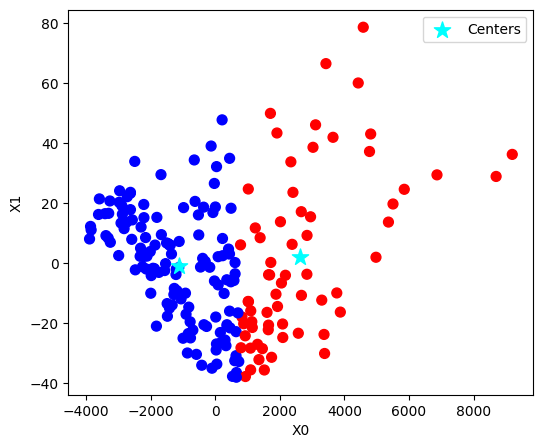

In [91]:
from sklearn.cluster import KMeans
X=X_train2.values
kmeans = KMeans(n_clusters = 2,# clustering in 2
                n_init = 1,# loop once
                random_state = 123).fit(X)

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s = 50, c = kmeans.labels_, cmap = plt.cm.bwr) 
plt.scatter(kmeans.cluster_centers_[:, 0], 
            kmeans.cluster_centers_[:, 1], 
            marker = '*', 
            s = 150,
            color = 'cyan', 
            label = 'Centers')
plt.legend(loc = 'best')
plt.xlabel('X0')
plt.ylabel('X1')

plt.show()

# kmode

In [92]:
from kmodes.kmodes import KModes

# random categorical data
data = X_train2.values
km = KModes(n_clusters=2, # clustering in 4
            init='Huang',
            n_init=5,# loop 5 times
            verbose=1)# print the processing, 0 means turn off

clusters = km.fit_predict(data)
print(km.cluster_centroids_)

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 792.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 0, cost: 792.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 0, cost: 792.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 0, cost: 792.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 0, cost: 792.0
Best run was number 1
[[-3.88782539e+03 -3.80182323e+01 -3.72554637e+01 -3.04006095e+01]
 [ 2.84121028e+03 -3.69502001e+00 -6.22942477e+00  1.99925135e+01]]


# Kmedoids

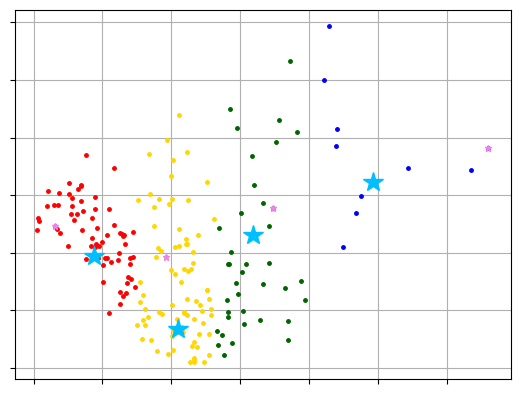

In [99]:
from pyclustering.cluster import cluster_visualizer
from pyclustering.cluster.center_initializer import kmeans_plusplus_initializer
from pyclustering.cluster.kmedoids import kmedoids
from pyclustering.utils import read_sample
import numpy, warnings 
numpy.warnings = warnings

sample = X_train2.iloc[:,:2].values

# initialize
initial_medoids = kmeans_plusplus_initializer(sample, 4, # 4 dots with more distance
                                              kmeans_plusplus_initializer.FARTHEST_CENTER_CANDIDATE).initialize(return_index=True)

# create instance of K-Medoids algorithm
kmedoids_instance = kmedoids(sample, 
                             initial_medoids)# the index of dots picked

# run cluster analysis and obtain results
kmedoids_instance.process()
clusters = kmedoids_instance.get_clusters()
medoids = kmedoids_instance.get_medoids()

# visualize clustering results
visualizer = cluster_visualizer(1)
visualizer.append_clusters(clusters, sample, 0)
visualizer.append_cluster([sample[index] for index in initial_medoids], marker='*', markersize=5)
visualizer.append_cluster(medoids, data=sample, marker='*', markersize=15)
visualizer.show();

# kprototype

In [118]:
from kmodes.kprototypes import KPrototypes
from sklearn import preprocessing

customers_norm = X_train2
kproto = KPrototypes(n_clusters=3,# clustering in 3
                     init='Cao')

# specify which columns in the data are categorical (columns 0 and 1)
clusters = kproto.fit_predict(customers_norm, categorical=[0, 1])
#join data with labels 
labels = pd.DataFrame(clusters)
labeledCustomers = pd.concat((customers_norm,labels),axis=1)
labeledCustomers = labeledCustomers.rename({0:'labels'},axis=1)

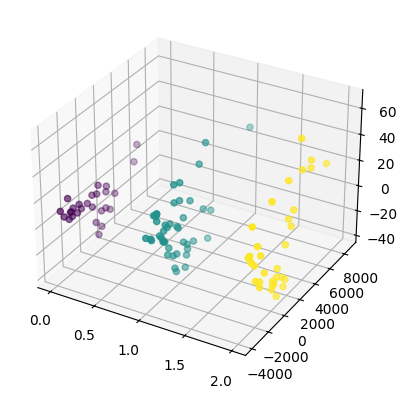

In [122]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")


ax.scatter(labeledCustomers.labels.astype('category').cat.codes, labeledCustomers.PC1, 
           labeledCustomers.PC2, c = labeledCustomers.labels) 

plt.show()

# Hierarchical clustering

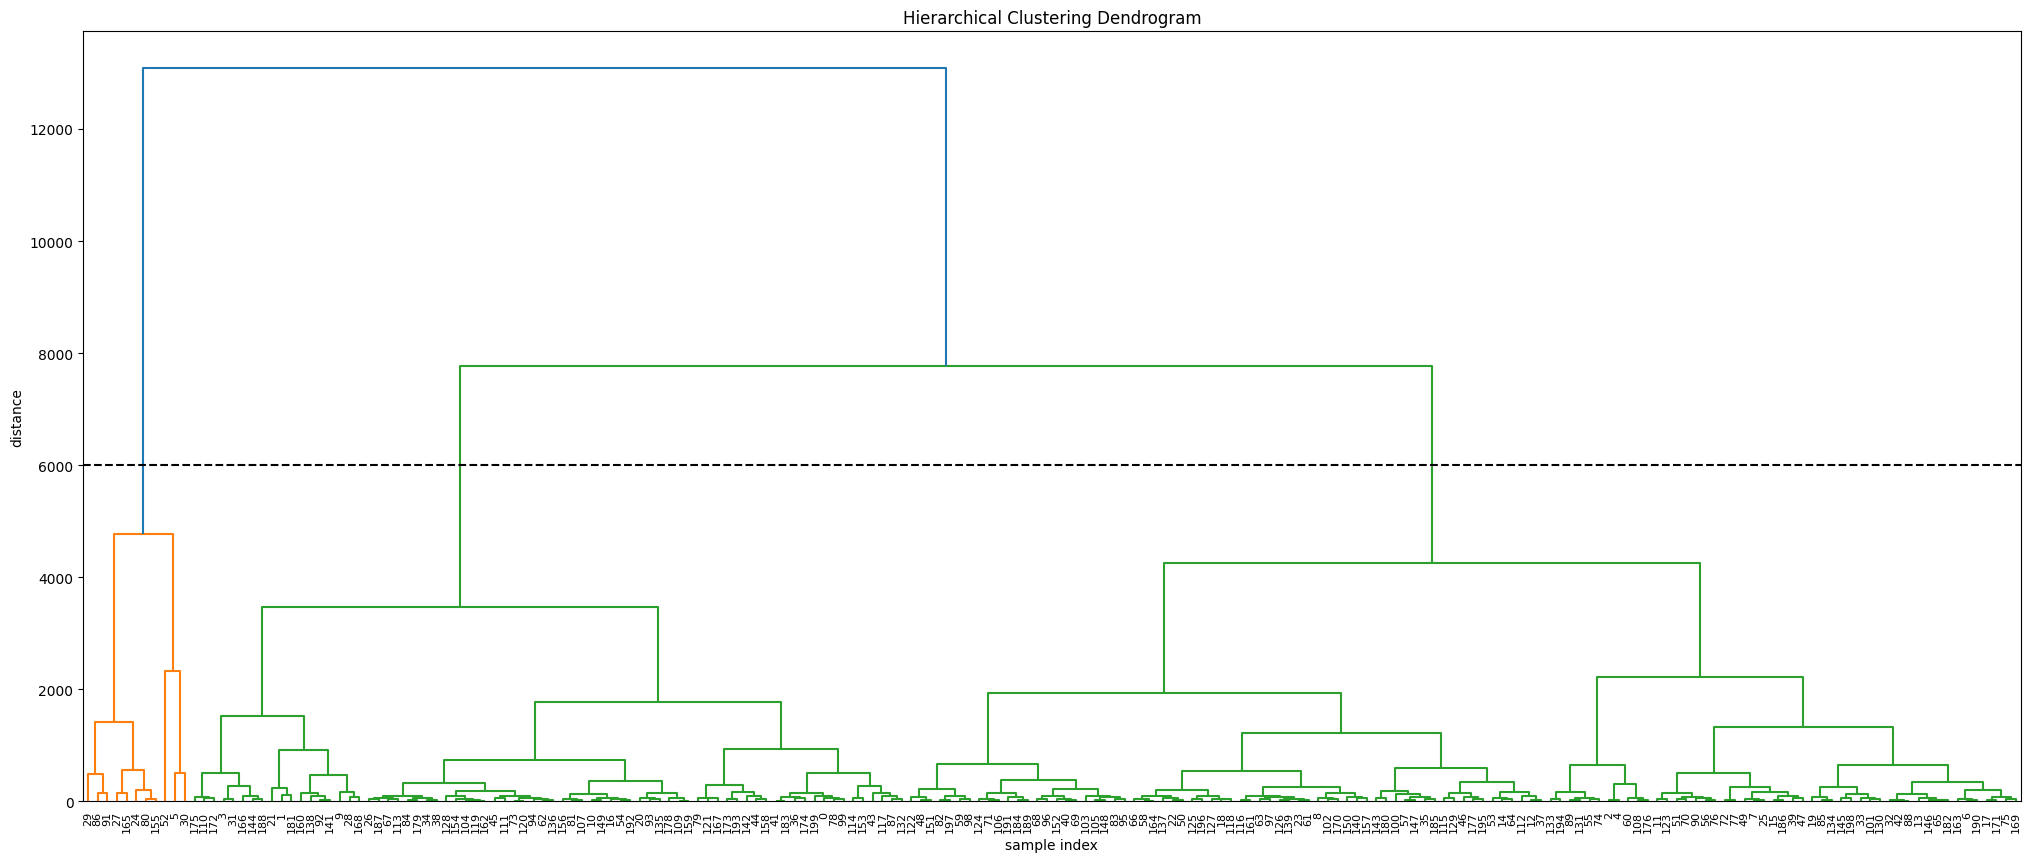

In [124]:
np.random.seed(123)
X = X_train2

from scipy.cluster.hierarchy import linkage
hc_complete = linkage(X, "complete")# 簇会比较紧凑
hc_average = linkage(X, "average")# 既不太紧也不太松
hc_single = linkage(X, "single")# 形成“链状”簇

from scipy.cluster.hierarchy import dendrogram

# calculate full dendrogram
plt.figure(figsize=(25, 10))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('sample index')
plt.ylabel('distance')
dendrogram(
    hc_complete,
    leaf_rotation=90.,  # rotates the x axis labels
    leaf_font_size=8.,  # font size for the x axis labels
)
plt.axhline(y=6000, c='k', ls='dashed')
plt.show()

In [125]:
from scipy.cluster.hierarchy import cut_tree
print(cut_tree(hc_single, n_clusters = 4).T) # Printing transpose just for space

[[0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 2 0 2 1 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 2 0 0 0 0 0 2 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


# EM

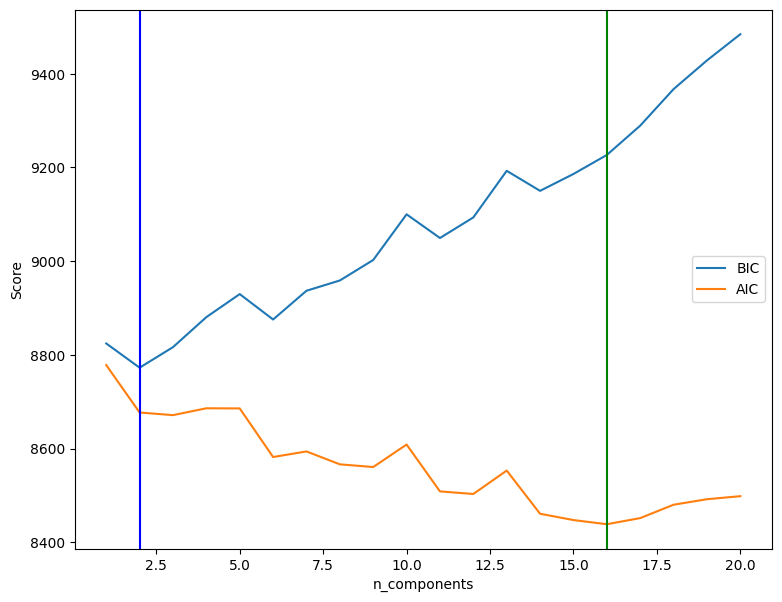

In [127]:
from sklearn.mixture import GaussianMixture

# the number of clustering
n_components = np.arange(1, 21)

# train GaussianMixture for each group
models = [GaussianMixture(n, covariance_type='full', random_state=0).fit(X_train2)
          for n in n_components]

fig, ax = plt.subplots(figsize=(9,7))

# change for aic and bic
ax.plot(n_components, [m.bic(X_train2) for m in models], label='BIC')# 简洁性
ax.plot(n_components, [m.aic(X_train2) for m in models], label='AIC')# 拟合效果

# find the least aic and bic automatically
ax.axvline(np.argmin([m.bic(X_train2) for m in models]) + 1, color='blue')
ax.axvline(np.argmin([m.aic(X_train2) for m in models]) + 1, color='green')

plt.legend(loc='best')
plt.xlabel('n_components')
plt.ylabel('Score') 
plt.show()

# neural network

In [128]:
## train a neural network classification
from sklearn.neural_network import MLPClassifier  
mlp = MLPClassifier(hidden_layer_sizes=(10, 10, 10),# 3 layers and 10*10*10 neurals
                    max_iter=1000)  
mlp.fit(X_train2, y_train2.ravel())
predictions = mlp.predict(X_test2)  

from sklearn.metrics import classification_report, confusion_matrix,r2_score
print(confusion_matrix(y_test2,predictions))  
print(classification_report(y_test2,predictions)) 

[[180   2]
 [ 17   1]]
              precision    recall  f1-score   support

           0       0.91      0.99      0.95       182
           1       0.33      0.06      0.10        18

    accuracy                           0.91       200
   macro avg       0.62      0.52      0.52       200
weighted avg       0.86      0.91      0.87       200



D:\install\anaconda\envs\good\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


(159987.13520788623, 0.25766049939809965)

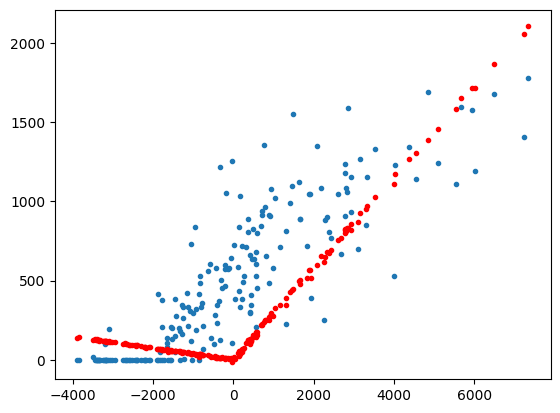

In [132]:
# for regression question
from sklearn.neural_network import MLPRegressor

##Single hidden layer, with 16 nodes and relu activation function
mlp = MLPRegressor(random_state=0, 
                   activation='relu',
                   hidden_layer_sizes=16)# one layer and 16 neurals
mlp.fit(X_train2, y_train1)

y_guess = mlp.predict(X_test2)

plt.plot(X_test2.iloc[:,0], y_test1, '.')
plt.plot(X_test2.iloc[:,0], y_guess, 'r.')

mean_squared_error(y_test1, y_guess), r2_score(y_test1, y_guess)